In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [89]:
df = pd.read_csv('clean_retail_dataset.csv')

In [90]:
df.head()

,OrderID,OrderDate,CustomerID,Country,Region,Product,Quantity,UnitPrice,Discount,ShippingMode,Category,Sales,Profit
0,10001,2024-05-10,1165,Germany,South,Headphones,9,1357,0.14,Standard,Accessories,12213,2548.376394
1,10002,2024-12-31,1033,UK,North,Tablet,4,51,0.17,Same Day,Electronics,204,6.142379
2,10003,2024-11-10,1016,Mexico,North,Smartwatch,7,306,0.31,Standard,Electronics,2142,324.025711
3,10004,2022-05-02,1164,Japan,West,Keyboard,6,613,0.19,Express,Accessories,3678,439.805380
4,10005,2023-04-12,1152,Japan,East,Laptop,2,1086,0.32,Express,Electronics,2172,-470.616919


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       999 non-null    int64  
 1   OrderDate     999 non-null    object 
 2   CustomerID    999 non-null    int64  
 3   Country       999 non-null    object 
 4   Region        999 non-null    object 
 5   Product       999 non-null    object 
 6   Quantity      999 non-null    int64  
 7   UnitPrice     999 non-null    int64  
 8   Discount      999 non-null    float64
 9   ShippingMode  999 non-null    object 
 10  Category      999 non-null    object 
 11  Sales         999 non-null    int64  
 12  Profit        999 non-null    float64
dtypes: float64(2), int64(5), object(6)
memory usage: 101.6+ KB


In [92]:
df.head(10)

,OrderID,OrderDate,CustomerID,Country,Region,Product,Quantity,UnitPrice,Discount,ShippingMode,Category,Sales,Profit
0,10001,2024-05-10,1165,Germany,South,Headphones,9,1357,0.14,Standard,Accessories,12213,2548.376394
1,10002,2024-12-31,1033,UK,North,Tablet,4,51,0.17,Same Day,Electronics,204,6.142379
2,10003,2024-11-10,1016,Mexico,North,Smartwatch,7,306,0.31,Standard,Electronics,2142,324.025711
3,10004,2022-05-02,1164,Japan,West,Keyboard,6,613,0.19,Express,Accessories,3678,439.805380
4,10005,2023-04-12,1152,Japan,East,Laptop,2,1086,0.32,Express,Electronics,2172,-470.616919
5,10006,2022-11-27,1121,Japan,East,Mouse,8,1946,0.23,Express,Accessories,15568,-594.310286
6,10007,2022-03-29,1075,India,North,Headphones,7,636,0.14,Express,Accessories,4452,1227.810868
7,10008,2024-05-21,1086,Japan,Central,Headphones,7,1044,0.32,Express,Accessories,7308,-150.373716
8,10009,2022-05-11,1116,UK,South,Tablet,8,1616,0.10,Same Day,Electronics,12928,3963.079622
9,10010,2024-02-09,1105,Brazil,East,Smartwatch,1,289,0.09,Express,Electronics,289,71.144757


##  Profitability Analysis

<Axes: ylabel='Profit'>

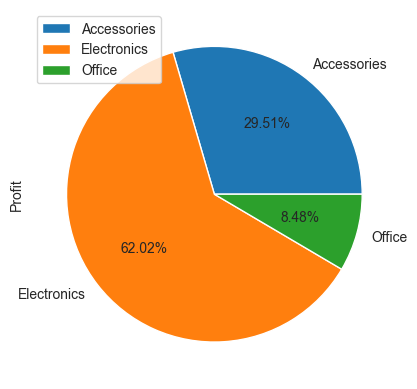

In [96]:
# Which category contributes the most to total profit?
# → Use: barplot or pie chart

df.groupby("Category")['Profit'].sum().plot(kind='pie',autopct='%1.2f%%',legend='Category')



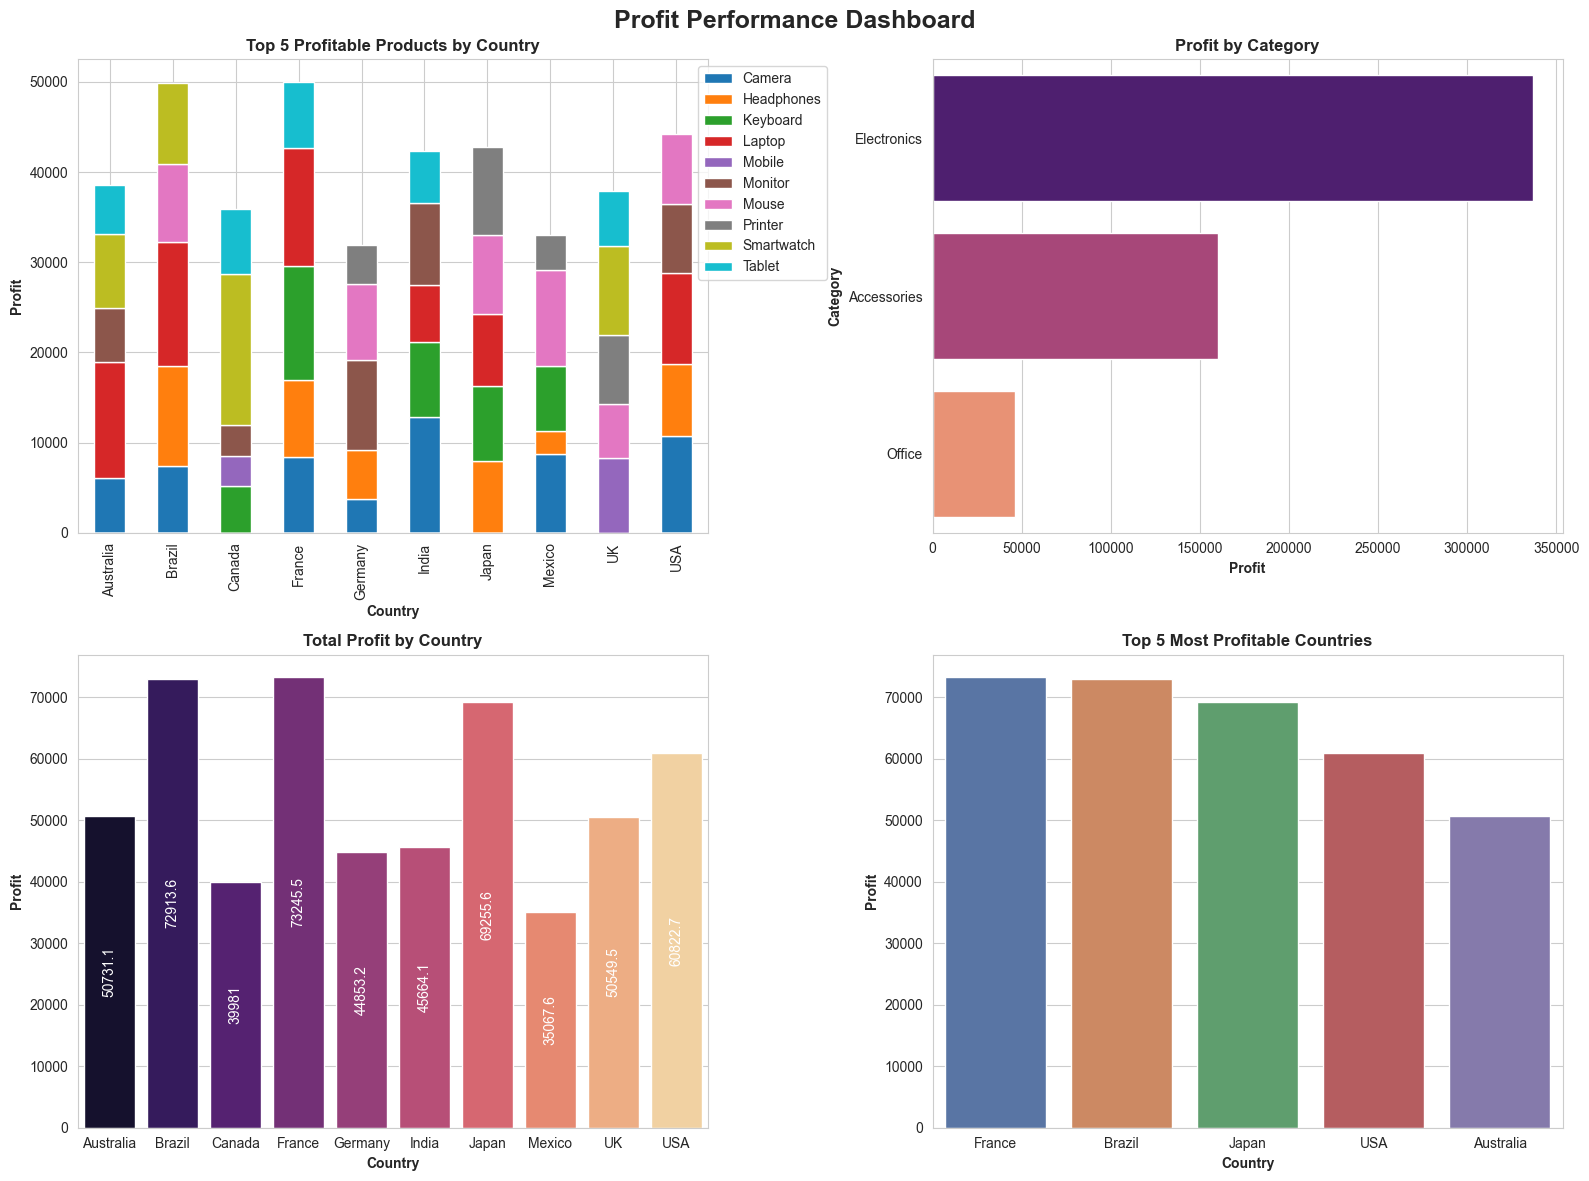

In [175]:
plt.figure(figsize=(16,12))
sns.set_style('whitegrid')

# Top 5 products generate highest profit (stacked)
plt.subplot(2,2,1)
top=df.groupby(['Product','Country'])[['Profit']].sum().reset_index()
top.sort_values(["Country","Profit"], ascending=[True,False],inplace=True)
top5 = top.groupby('Country').head(5)
piot=top5.pivot_table(index='Country',columns='Product',values='Profit')
piot.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca()
)
plt.title("Top 5 Profitable Products by Country",fontweight='bold')
plt.xlabel("Country",fontweight='bold')
plt.ylabel("Profit",fontweight='bold')
plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))


# Category highest and lowest profit
plt.subplot(2,2,2)
a=df.groupby("Category")['Profit'].sum().reset_index().sort_values('Profit',ascending=False)
sns.barplot(data=a,x='Profit',y='Category',hue="Category",palette='magma')
plt.title("Profit by Category",fontweight='bold')
plt.xlabel('Profit',fontweight='bold')
plt.ylabel('Category',fontweight='bold')


# Country generating most profit
plt.subplot(2,2,3)
a= df.groupby('Country')['Profit'].sum().reset_index()
ax=sns.barplot(data=a,x='Country',y='Profit',hue='Country',palette='magma')
plt.title("Total Profit by Country",fontweight='bold')
plt.xlabel("Country",fontweight='bold')
plt.ylabel("Profit",fontweight='bold')
for i in ax.containers:
    ax.bar_label(i,label_type='center',color='white',rotation=90)


# Top 5 most profitable countries
plt.subplot(2,2,4)
top5 = df.groupby('Country')['Profit'].sum().nlargest(5).reset_index()
sns.barplot(data=top5,x='Country',y='Profit',hue="Country",palette='deep')
plt.title("Top 5 Most Profitable Countries",fontweight='bold')
plt.xlabel("Country",fontweight='bold')
plt.ylabel("Profit",fontweight='bold')


plt.suptitle("Profit Performance Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Sales vs Profit Relationship


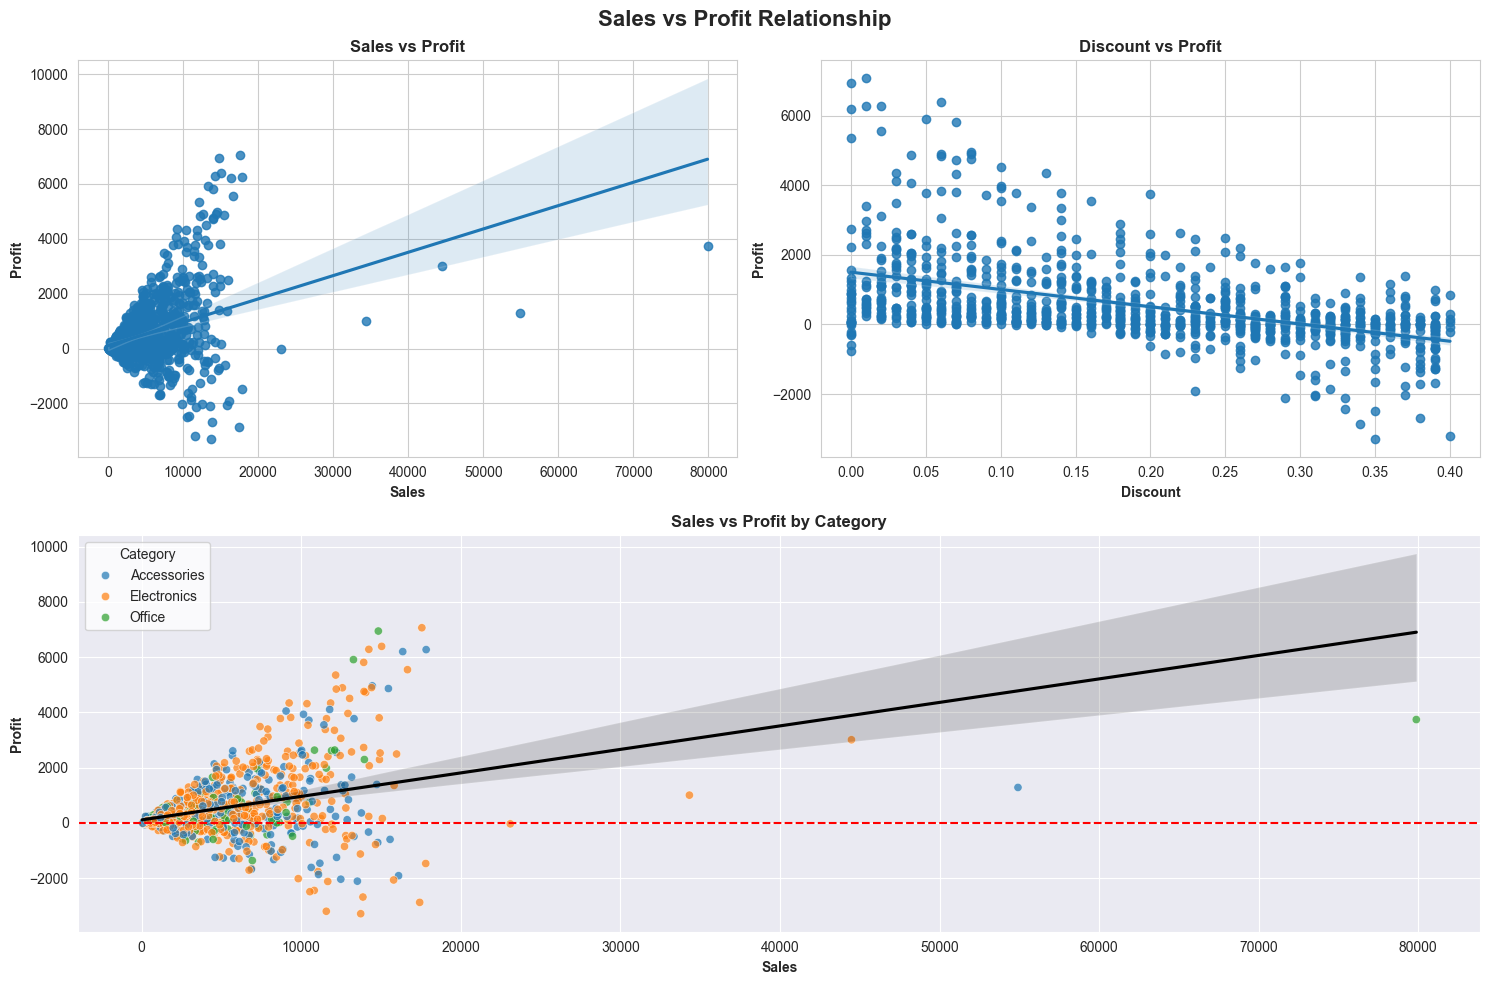

In [ ]:
plt.figure(figsize=(15,10))

# 1ales vs Profit
plt.subplot2grid((2,2),(0,0))
sns.set_style('whitegrid')
sns.regplot(data=df,x="Sales",y='Profit')
plt.xlabel('Sales',fontweight='bold')
plt.ylabel('Profit',fontweight='bold')
plt.title("Sales vs Profit",fontweight='bold')

# 2Discount vs Profit
plt.subplot2grid((2,2),(0,1))
sns.set_style('darkgrid')
sns.regplot(data=df,x="Discount",y='Profit')
plt.xlabel('Discount',fontweight='bold')
plt.ylabel('Profit',fontweight='bold')
plt.title("Discount vs Profit",fontweight='bold')

# 3Large Plot (spanning both columns)
plt.subplot2grid((2,2),(1,0), colspan=2)
sns.set_style('whitegrid')

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    alpha=0.7
)

sns.regplot(
    data=df,
    x='Sales',
    y='Profit',
    scatter=False,
    color='black'
)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel('Sales',fontweight='bold')
plt.ylabel('Profit',fontweight='bold')
plt.title("Sales vs Profit by Category",fontweight='bold')

plt.suptitle("Sales vs Profit Relationship", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## Distribution Analysis


C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\2254597611.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Profit', data=df, palette='Set2', showmeans=True)


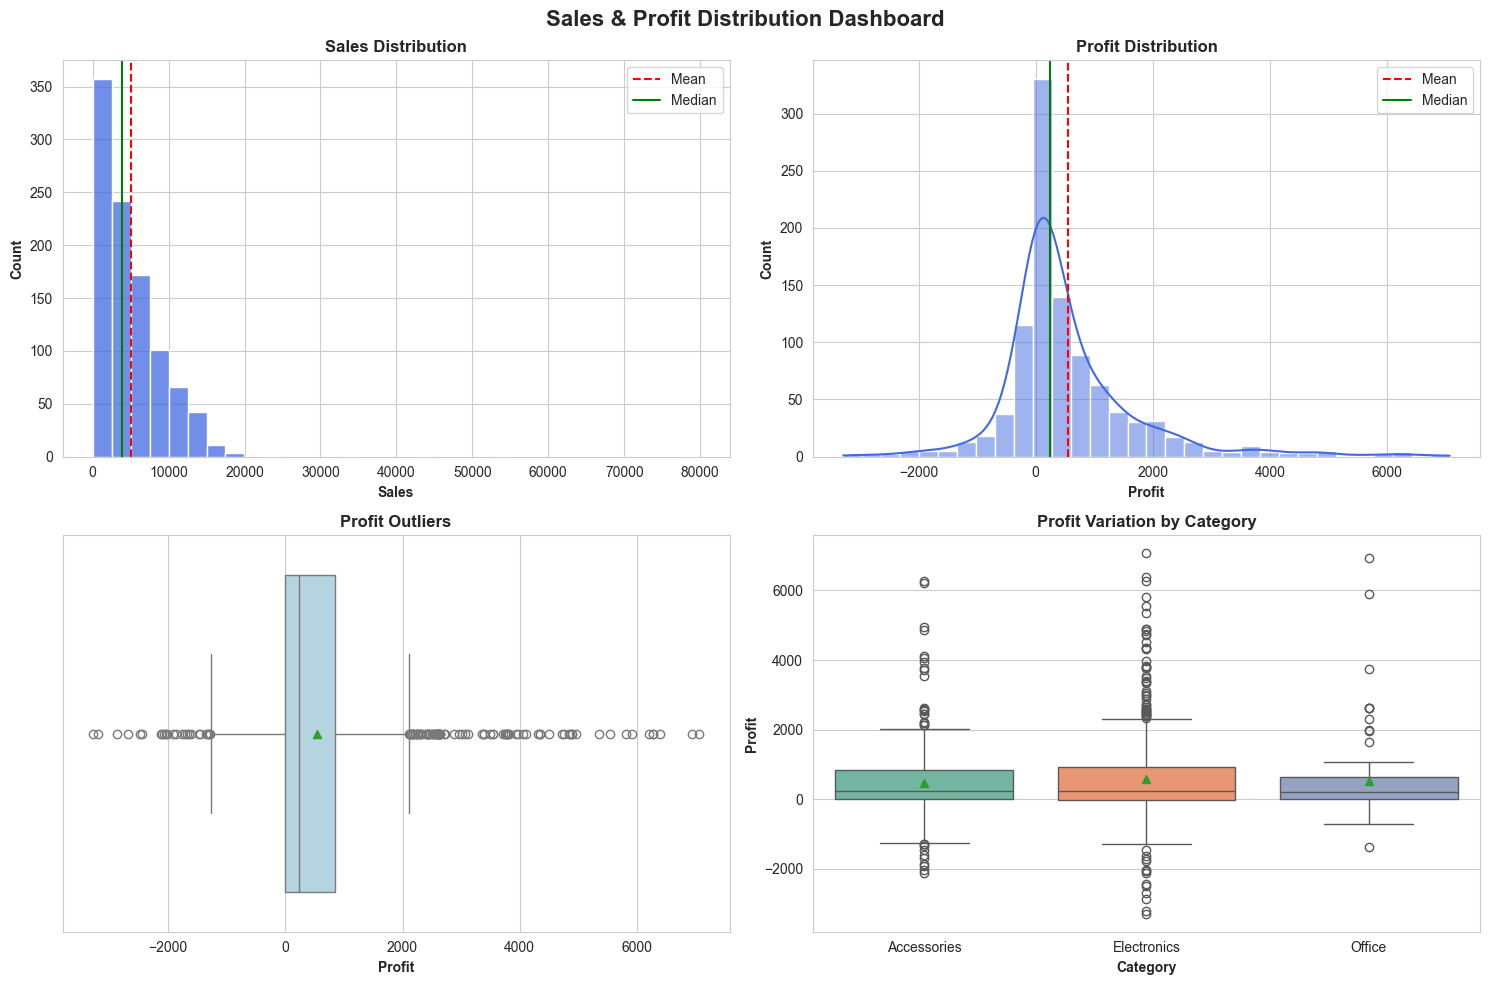

In [ ]:
# Sales & Profit Distribution Dashboard

plt.figure(figsize=(15,10))
sns.set_style("whitegrid")
# Sales Distribution
plt.subplot(2,2,1)
sns.histplot(data=df, x='Sales', bins=32, color='royalblue')
plt.axvline(df['Sales'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Sales'].median(), color='green', label='Median')
plt.title("Sales Distribution",fontweight='bold')
plt.xlabel("Sales",fontweight='bold')
plt.ylabel("Count",fontweight='bold')
plt.legend()

# Profit Distribution
plt.subplot(2,2,2)
sns.histplot(data=df, x='Profit', kde=True, bins=32, color='royalblue')
plt.axvline(df['Profit'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Profit'].median(), color='green', label='Median')
plt.title("Profit Distribution",fontweight='bold')
plt.xlabel("Profit",fontweight='bold')
plt.ylabel("Count",fontweight='bold')
plt.legend()

# Profit Outliers
plt.subplot(2,2,3)
sns.boxplot(x=df['Profit'], color='lightblue', showmeans=True)
plt.title("Profit Outliers",fontweight='bold')
plt.xlabel("Profit",fontweight='bold')

# Profit Variation by Category
plt.subplot(2,2,4)
sns.boxplot(x='Category', y='Profit', data=df, palette='Set2', showmeans=True)
plt.title("Profit Variation by Category",fontweight='bold')
plt.xlabel("Category",fontweight='bold')
plt.ylabel("Profit",fontweight='bold')

plt.suptitle("Sales & Profit Distribution Dashboard", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Discount Impact Analysis 


C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\2951592193.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Country', y='Discount',


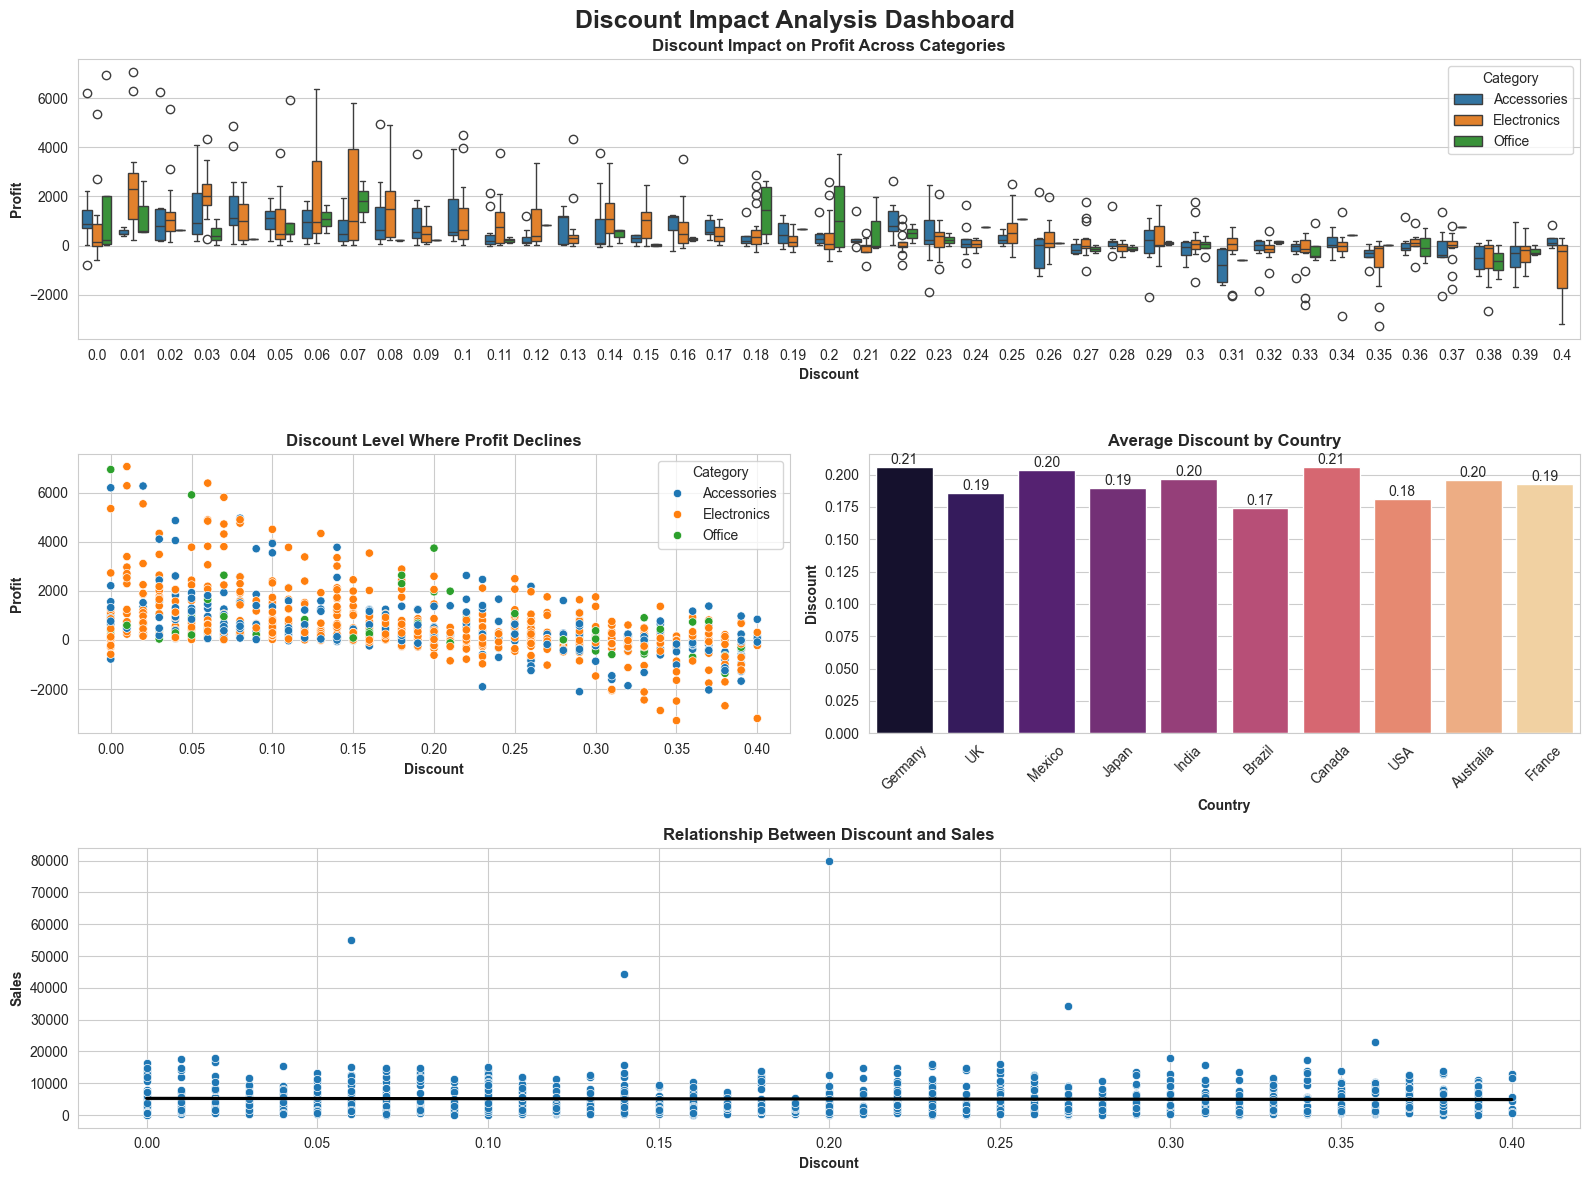

In [179]:
plt.figure(figsize=(16,12))
sns.set_style("whitegrid")

# Large plot (Discount impact on profit)
plt.subplot2grid((3,2),(0,0), colspan=2)
sns.boxplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title("Discount Impact on Profit Across Categories", fontweight='bold')
plt.xlabel("Discount", fontweight='bold')
plt.ylabel("Profit", fontweight='bold')


# Small plot (Discount vs Profit)
plt.subplot2grid((3,2),(1,0))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title("Discount Level Where Profit Declines", fontweight='bold')
plt.xlabel("Discount", fontweight='bold')
plt.ylabel("Profit", fontweight='bold')


# Small plot (Average Discount by Country)
plt.subplot2grid((3,2),(1,1))

ax = sns.barplot(data=df, x='Country', y='Discount',
                 estimator='mean', palette='magma', errorbar=None)
plt.title("Average Discount by Country", fontweight='bold')
plt.xlabel("Country", fontweight='bold')
plt.ylabel("Discount", fontweight='bold')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


# Large plot (Discount vs Sales)
plt.subplot2grid((3,2),(2,0), colspan=2)
sns.scatterplot(data=df, x='Discount', y='Sales')
sns.regplot(data=df, x='Discount', y='Sales', scatter=False, color='black')
plt.title("Relationship Between Discount and Sales", fontweight='bold')
plt.xlabel("Discount", fontweight='bold')
plt.ylabel("Sales", fontweight='bold')


plt.suptitle("Discount Impact Analysis Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Regional Performance


C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\1358191068.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=a, x='Region', y='Product', palette='Set2')


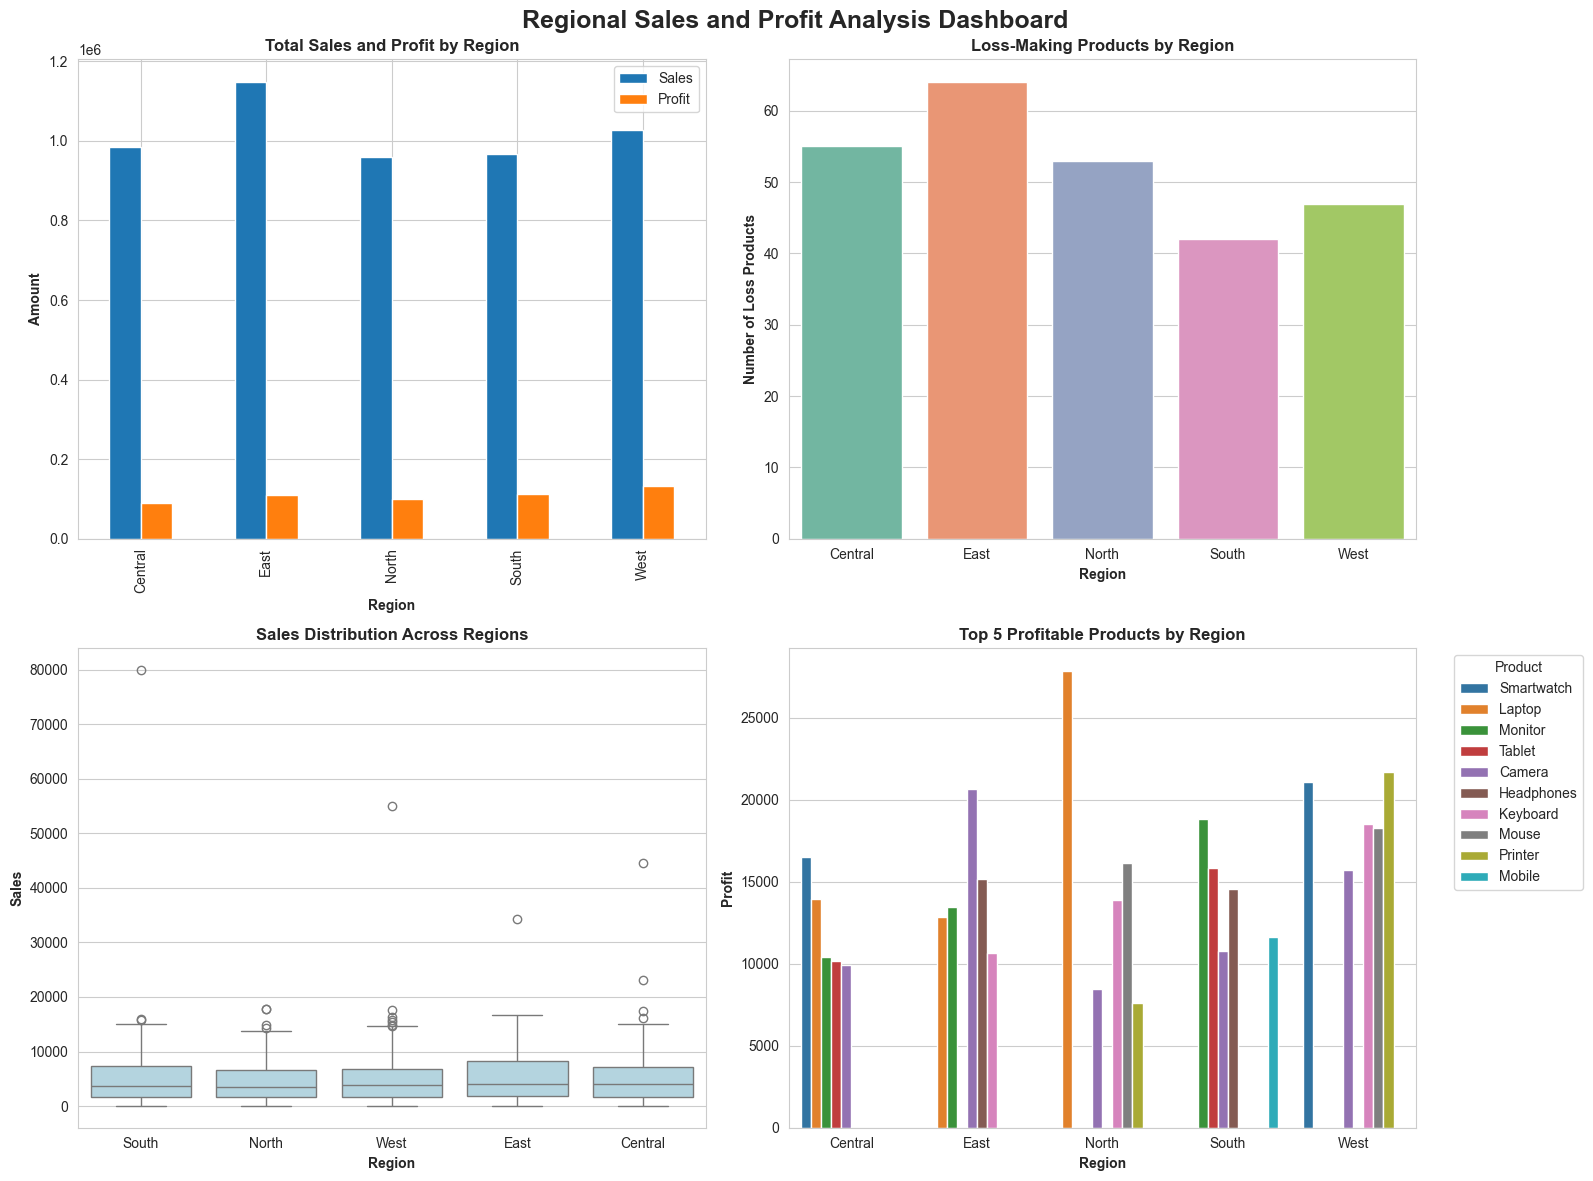

In [181]:
plt.figure(figsize=(16,12))
sns.set_style("whitegrid")

# Sales and Profit by Region
plt.subplot(2,2,1)
region_data = df.groupby("Region")[["Sales","Profit"]].sum()
region_data.plot(kind='bar', ax=plt.gca())
plt.title("Total Sales and Profit by Region", fontweight='bold')
plt.xlabel("Region", fontweight='bold')
plt.ylabel("Amount", fontweight='bold')


# Regions with Most Loss-Making Products
plt.subplot(2,2,2)
loss = df[df['Profit'] < 0]
a = loss.groupby('Region')['Product'].count().reset_index()
sns.barplot(data=a, x='Region', y='Product', palette='Set2')
plt.title("Loss-Making Products by Region", fontweight='bold')
plt.xlabel("Region", fontweight='bold')
plt.ylabel("Number of Loss Products", fontweight='bold')


# Sales Distribution Across Regions
plt.subplot(2,2,3)
sns.boxplot(data=df, x='Region', y='Sales', color='lightblue')
plt.title("Sales Distribution Across Regions", fontweight='bold')
plt.xlabel("Region", fontweight='bold')
plt.ylabel("Sales", fontweight='bold')


# Top 5 Products in Each Region by Profit
plt.subplot(2,2,4)
a = df.groupby(['Region','Product'])['Profit'].sum().reset_index()
a = a.sort_values(['Region','Profit'], ascending=[True,False])
top5 = a.groupby('Region').head(5)
sns.barplot(
    data=top5,
    x='Region',
    y='Profit',
    hue='Product'
)
plt.title("Top 5 Profitable Products by Region", fontweight='bold')
plt.xlabel("Region", fontweight='bold')
plt.ylabel("Profit", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05,1), title="Product")

plt.suptitle("Regional Sales and Profit Analysis Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Category & Product Analysis

C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\1407793653.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=a, x='Category', y="Quantity", palette='Set2', width=0.5)
C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\1407793653.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='Category', y='Sales', palette='magma')


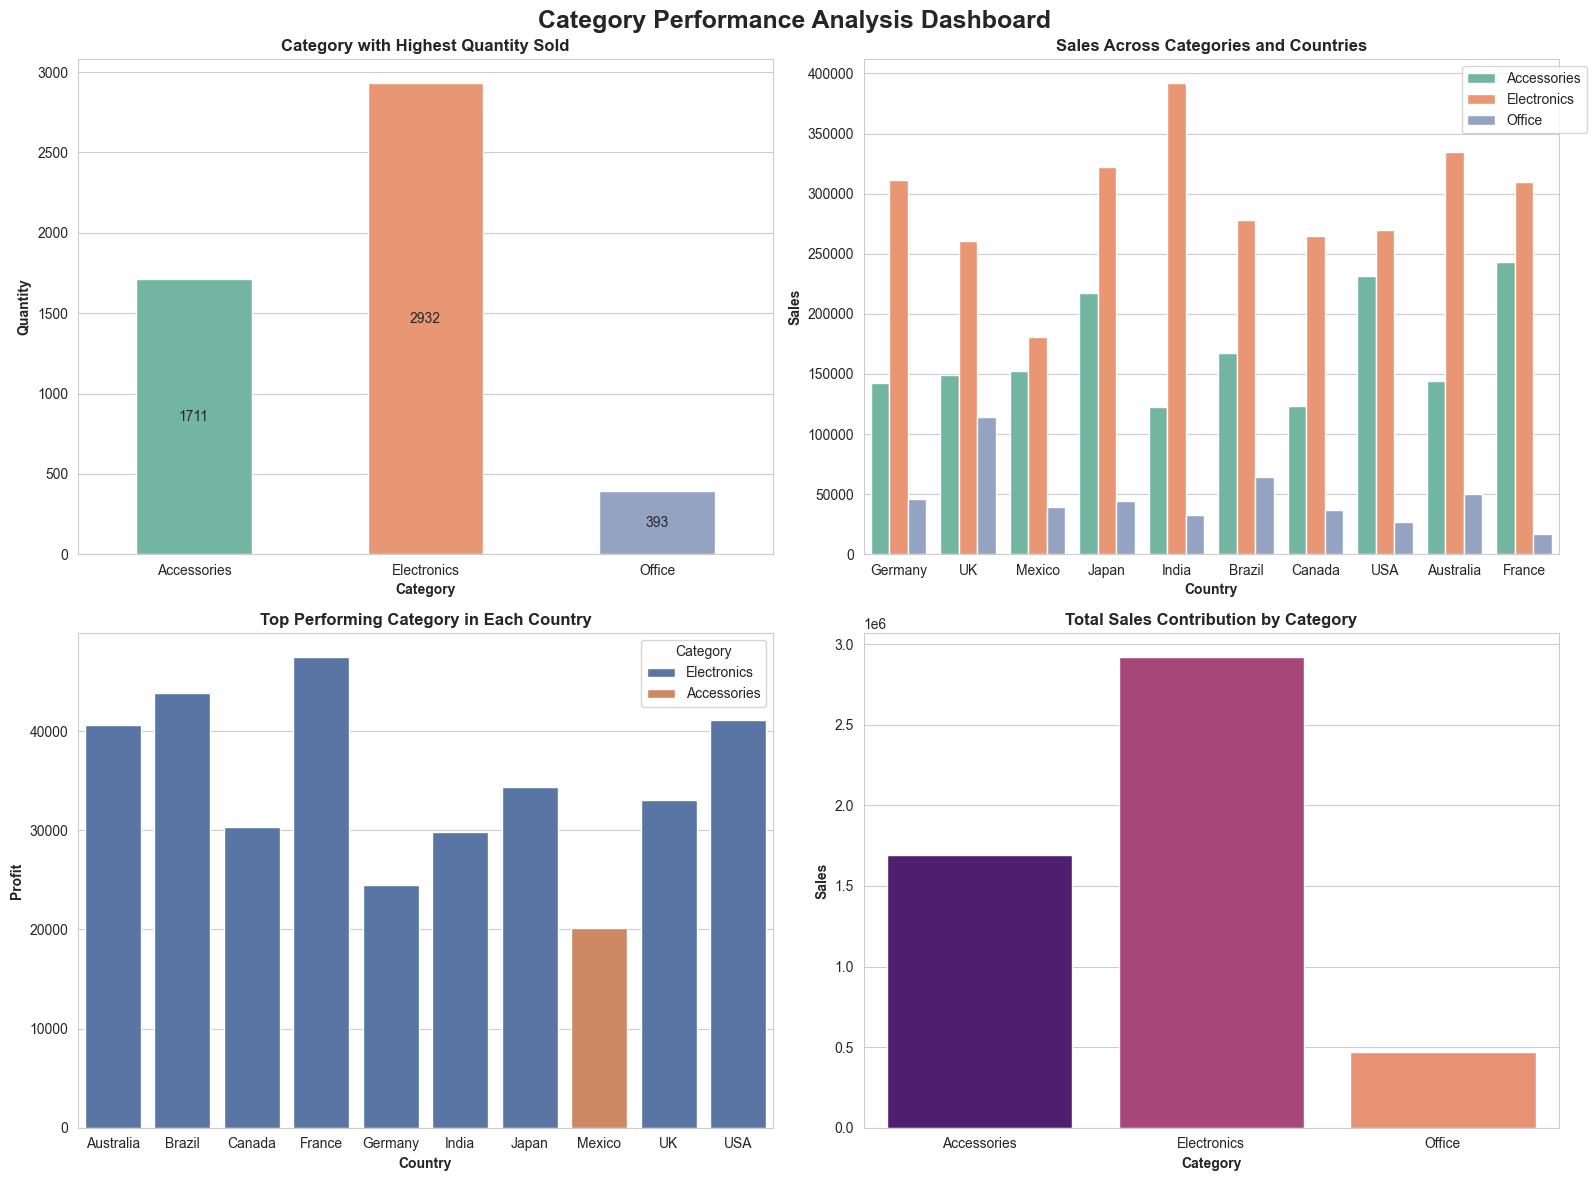

In [ ]:
plt.figure(figsize=(16,12))
sns.set_style("whitegrid")

#  Which category sells the highest quantity
plt.subplot(2,2,1)
a = df.groupby('Category')['Quantity'].sum().reset_index()
ax = sns.barplot(data=a, x='Category', y="Quantity", palette='Set2', width=0.5)
plt.title('Category with Highest Quantity Sold', fontweight='bold')
plt.xlabel('Category',fontweight='bold')
plt.ylabel('Quantity',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, label_type='center')


#  Compare sales across categories and countries
plt.subplot(2,2,2)
sns.barplot(
    data=df,
    x='Country',
    y='Sales',
    hue='Category',
    estimator=sum,
    errorbar=None,
    palette='Set2'
)
plt.title("Sales Across Categories and Countries", fontweight='bold')
plt.xlabel('Country',fontweight='bold')
plt.ylabel('Sales',fontweight='bold')
plt.legend(bbox_to_anchor=(1.05,1))


#  Top performing category in each country
plt.subplot(2,2,3)
a = df.groupby(['Country','Category'])['Profit'].sum().reset_index()
a = a.sort_values(['Country','Profit'],ascending=[True,False])
top = a.groupby('Country').head(1)
sns.barplot(data=top, x='Country', y='Profit', hue='Category', palette='deep')
plt.title("Top Performing Category in Each Country", fontweight='bold')
plt.xlabel('Country',fontweight='bold')
plt.ylabel('Profit',fontweight='bold')


# Category Sales Contribution
plt.subplot(2,2,4)
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(data=cat_sales, x='Category', y='Sales', palette='magma')
plt.title("Total Sales Contribution by Category", fontweight='bold')
plt.xlabel("Category", fontweight='bold')
plt.ylabel("Sales", fontweight='bold')

plt.suptitle("Category Performance Analysis Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis

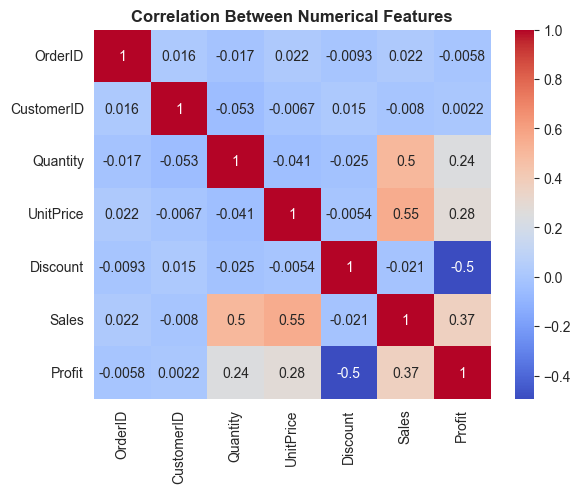

In [124]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Between Numerical Features',fontweight='bold')
plt.show()

## Advanced Visualization Questions (Real Data Science Level)


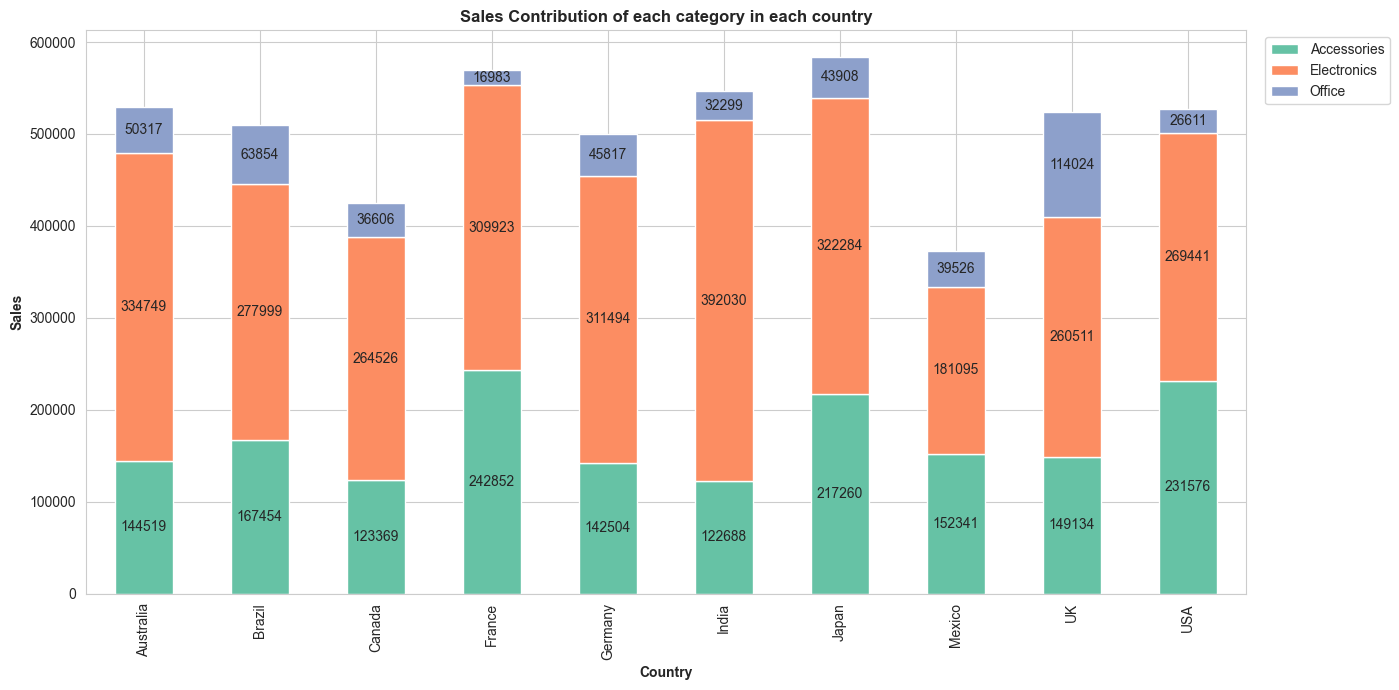

In [125]:
# Show sales contribution of each category in each country
colors = sns.color_palette('Set2')
a = df.groupby(['Country','Category'])['Sales'].sum().reset_index()
sns.set_style('whitegrid')
piot = a.pivot(index='Country',columns='Category',values='Sales')

ax = piot.plot(
    figsize=(14,7),
    kind="bar",
    color=colors,
    stacked=True

)
plt.legend(bbox_to_anchor=(1.13,1))
plt.title("Sales Contribution of each category in each country",fontweight='bold')
plt.xlabel("Country",fontweight='bold')
plt.ylabel("Sales",fontweight='bold')
plt.tight_layout()
for i in ax.containers:
    ax.bar_label(i,label_type='center')

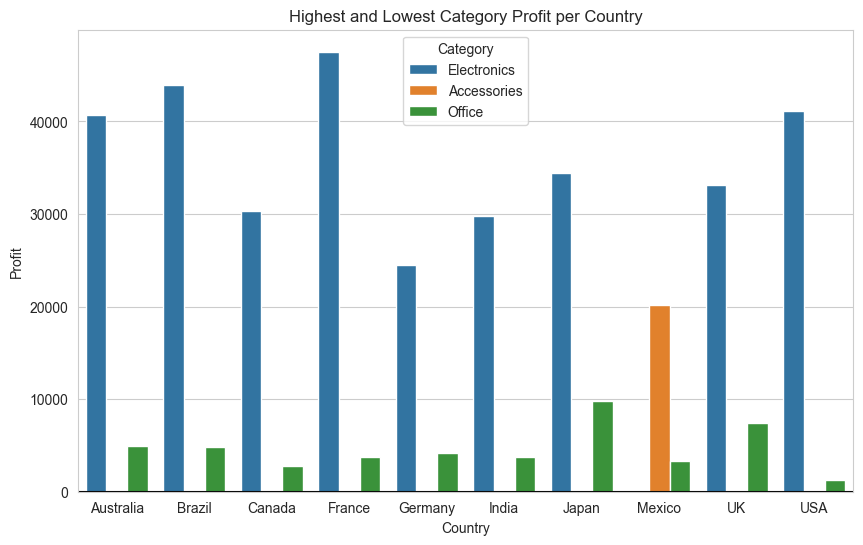

In [ ]:
# Which category is profitable in one country but loss in another?
top = a.loc[a.groupby('Country')['Profit'].idxmax()]
low = a.loc[a.groupby('Country')['Profit'].idxmin()]
result = pd.concat([top, low])
plt.figure(figsize=(10,6))

sns.barplot(
    data=result,
    x='Country',
    y='Profit',
    hue='Category'
)

plt.axhline(0,color='black')
plt.title("Highest and Lowest Category Profit per Country")

plt.show()

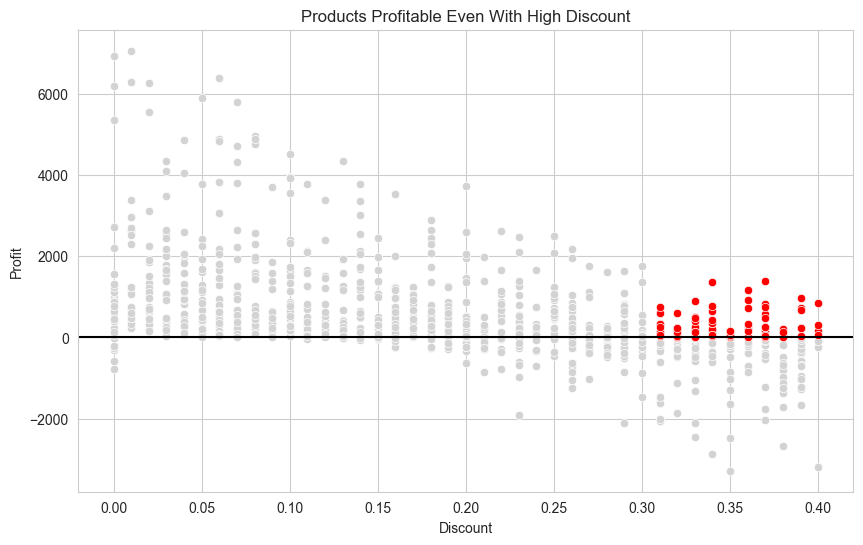

In [ ]:
# Find products where high discount still gives high profit
high_profit = df[(df['Discount'] > 0.3) & (df['Profit'] > 0)]
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Discount', y='Profit', color='lightgray')

sns.scatterplot(
    data=high_profit,
    x='Discount',
    y='Profit',
    color='red'
)

plt.axhline(0, color='black')

plt.title("Products Profitable Even With High Discount")

plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_19408\2532454655.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='Category', y='Profit', palette='Set2')


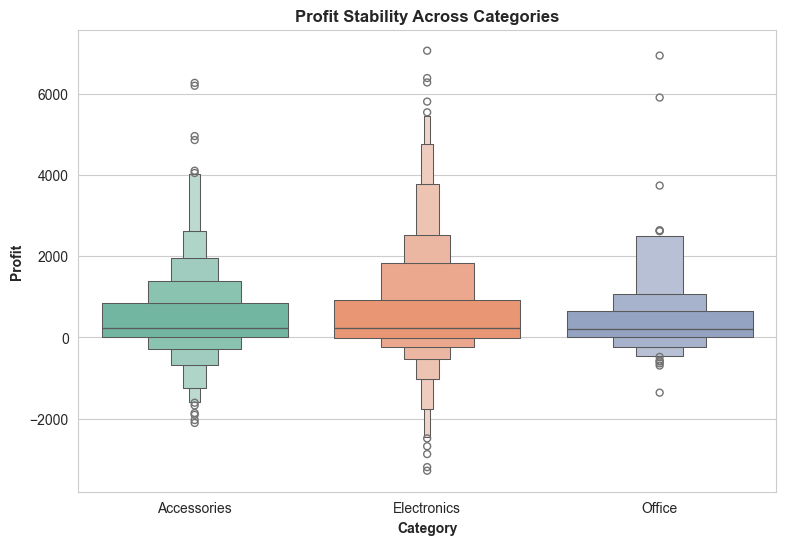

In [ ]:
# Which category has the most stable profit distribution?
plt.figure(figsize=(9,6))
sns.set_style('whitegrid')
sns.boxenplot(data=df, x='Category', y='Profit', palette='Set2')
plt.title("Profit Stability Across Categories", fontweight='bold')
plt.xlabel("Category", fontweight='bold')
plt.ylabel("Profit", fontweight='bold')

plt.show()

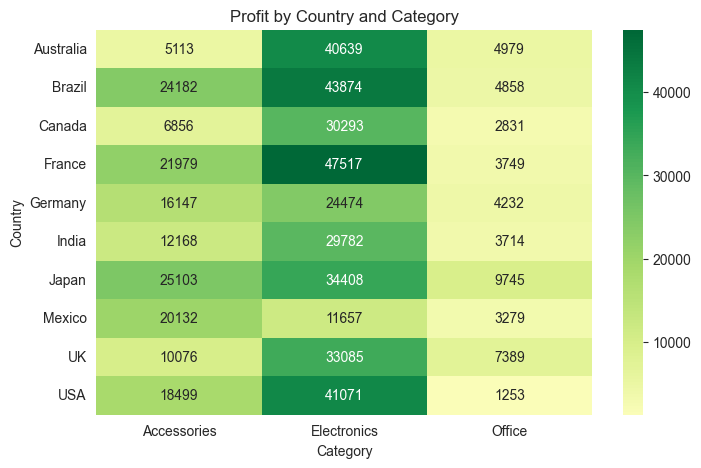

In [133]:
# Create a heatmap of profit by Country and Category
# → Use: pivot_table + heatmap
piot = df.pivot_table(index='Country',columns='Category',values='Profit',aggfunc='sum')
plt.figure(figsize=(8,5))

sns.heatmap(
    piot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Profit by Country and Category")
plt.xlabel("Category")
plt.ylabel("Country")

plt.show()

## Very Advanced


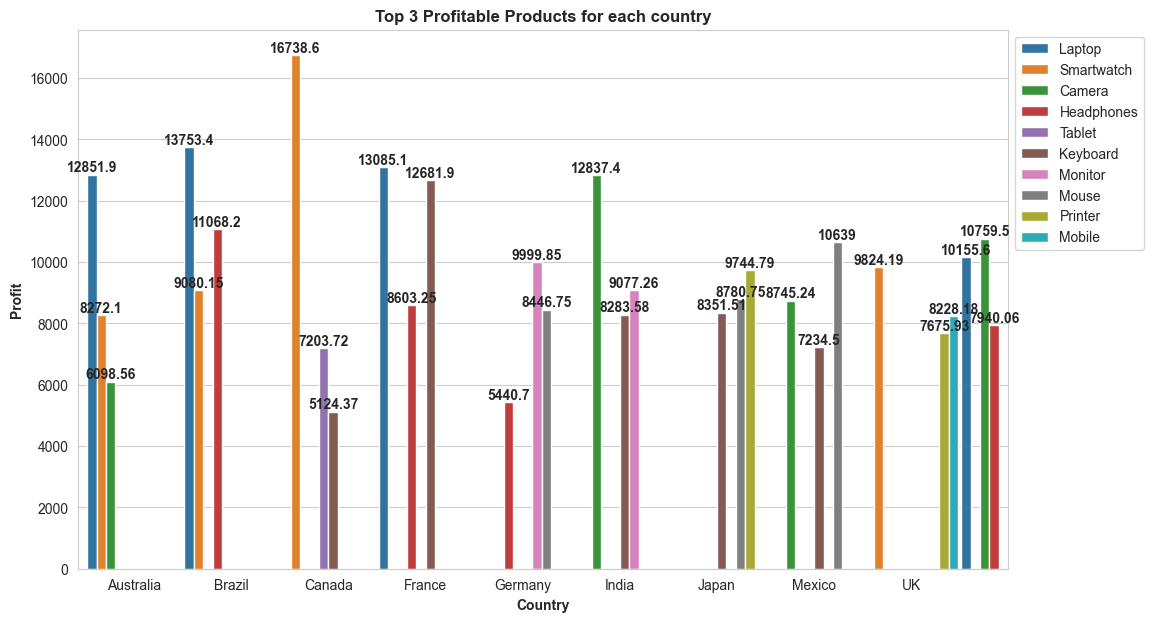

In [134]:
# Create top 3 profitable products for each country

temp = df.groupby(['Country','Product'])['Profit'].sum().reset_index()
temp.sort_values(['Country','Profit'],ascending=[True,False],inplace=True)
top3 = temp.groupby('Country').head(3)
sns.set_style('whitegrid')
plt.figure(figsize=(12,7))
ax = sns.barplot(data=top3 , x='Country' , y='Profit' , hue='Product',width=0.97)
plt.title("Top 3 Profitable Products for each country",fontweight='bold')
plt.xlabel('Country' , fontweight='bold')
plt.ylabel('Profit' , fontweight='bold')
plt.legend(bbox_to_anchor=(1,1))
plt.margins(x=0.01)
for i in ax.containers:
    ax.bar_label(i,fontweight='bold')



plt.show()

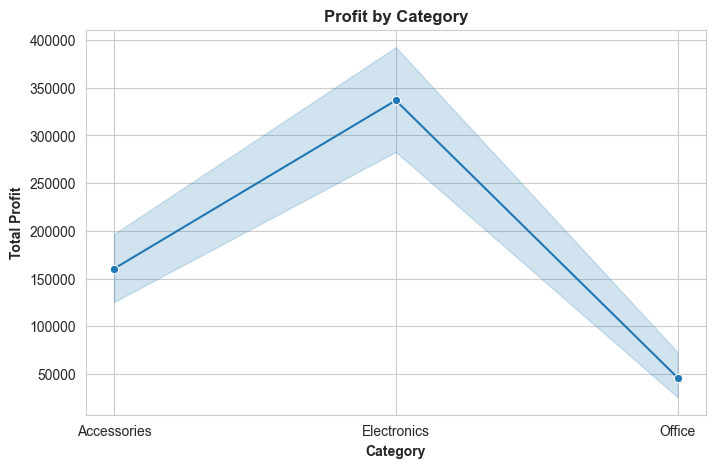

In [135]:
# Create profit trend by category
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='Category',
    y='Profit',
    estimator='sum',
    marker='o'
)

plt.title("Profit by Category",fontweight='bold')
plt.xlabel("Category",fontweight='bold')
plt.ylabel("Total Profit",fontweight='bold')

plt.show()

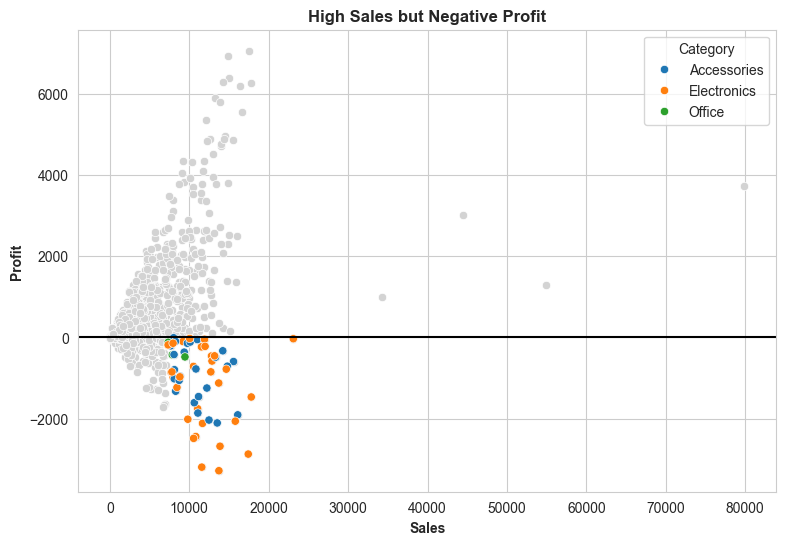

In [138]:
# A quantile divides data into equal parts.

# Example:

# Quantile	Meaning
# 0.25	25% of values are below this
# 0.50	Median (50%)
# 0.75	Top 25% threshold
# 0.90	Top 10% threshold
threshold = df['Sales'].quantile(0.75)
loss = df[(df['Sales'] > threshold) & (df['Profit'] < 0)]
plt.figure(figsize=(9,6))
sns.set_style('whitegrid')
sns.scatterplot(data=df, x='Sales', y='Profit', color='lightgray')
sns.scatterplot(data=loss, x='Sales', y='Profit', hue='Category')


plt.title("High Sales but Negative Profit", fontweight='bold')
plt.xlabel("Sales", fontweight='bold')
plt.ylabel("Profit", fontweight='bold')

plt.axhline(0, color='black')

plt.show()

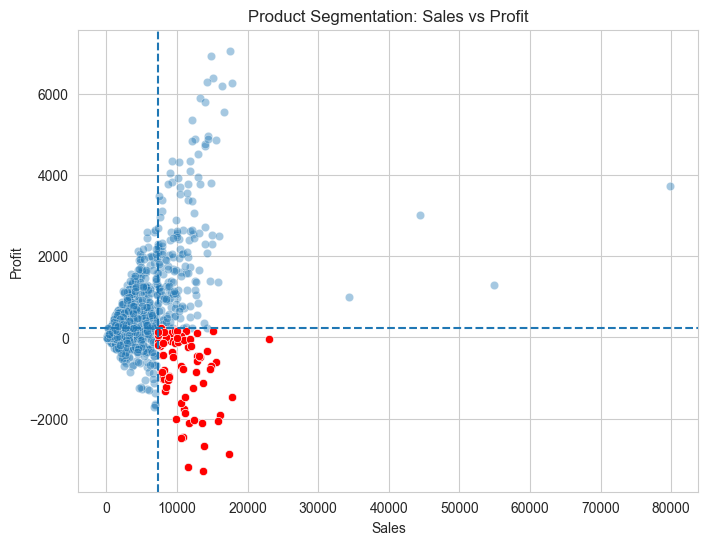

In [139]:
# Segment products into
# High profit
# High sales but low profit
# Low sales
# thresholds
profit_threshold = df['Profit'].quantile(0.50)
high_sales_threshold = df['Sales'].quantile(0.75)
low_sales_threshold = df['Sales'].quantile(0.25)

# High profit products
high_profit = df[df['Profit'] > profit_threshold]

# High sales but low profit
high_sales_low_profit = df[
    (df['Sales'] > high_sales_threshold) &
    (df['Profit'] < profit_threshold)
]

# Low sales products
low_sales = df[df['Sales'] < low_sales_threshold]

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.4)
sns.scatterplot(data=high_sales_low_profit, x='Sales', y='Profit', color='red')

plt.axhline(profit_threshold, linestyle='--')
plt.axvline(high_sales_threshold, linestyle='--')

plt.title("Product Segmentation: Sales vs Profit")

plt.show()


In [183]:
#15️⃣ Best selling product in each region
pivot = df.pivot_table(values="Sales",index="Region",columns="Product")
pivot["Max Sales"] = pivot.max(axis=1)
pivot["Best Selling Product"] = pivot.idxmax(axis=1)
pivot['Best Selling Product']

Region
Central        Camera
East           Tablet
North          Tablet
South         Printer
West       Headphones
Name: Best Selling Product, dtype: object

In [187]:
df.OrderDate = pd.to_datetime(df['OrderDate'],errors='coerce')

In [188]:
# Find the day with highest sales.
df.resample('D',on="OrderDate")["Sales"].sum().reset_index().sort_values(by="OrderDate").nlargest(1,columns="Sales")

,OrderDate,Sales
666,2023-10-29,79875


In [189]:
#Top 5 ncustomers by revenue
df.groupby("CustomerID")["Sales"].sum().reset_index().nlargest(5,"Sales").sort_values(by="Sales",ascending=False)

,CustomerID,Sales
156,1158,101515
90,1091,84252
175,1177,67056
70,1071,64151
87,1088,61423


In [190]:
#Customer purchase frequency and find top 5 customers
df.groupby("CustomerID")["OrderID"].count().reset_index().rename(columns={"OrderID":"OrderID_Count"}).nlargest(5,"OrderID_Count")

,CustomerID,OrderID_Count
11,1011,12
35,1036,12
37,1038,11
70,1071,10
25,1025,9


In [191]:
#Top 10 recent buyers
today = df["OrderDate"].max()
df.groupby("CustomerID")["OrderDate"].max().apply(lambda x: (today - x)).sort_values().nsmallest(10)

CustomerID
1033    0 days
1061    0 days
1173    2 days
1106    3 days
1125    3 days
1160    7 days
1097    9 days
1035    9 days
1172   13 days
1130   14 days
Name: OrderDate, dtype: timedelta64[ns]